# Cross-Model Current-Run Trade-Off Plots

Every other notebook under `notebooks/tradeoff_analysis/` isolates one mechanism
*inside* one model family and pushes the other families into the grey
off-scale gutters. This one inverts that: the five native baselines are the
subject, they keep their colour, and no mechanism arms are drawn. For now the
matrix is exactly one run per family — the baseline — which is enough to place
the families relative to one another on the FPA--TICE plane.

| family | run directory |
| --- | --- |
| `hcast` | `hcast_<dataset>` |
| `hrn` | `hrn_<dataset>_level_conditional` |
| `hiercos` | `hiercos_<dataset>_global_softmax_ce_reg_baseline_kl_leaf` |
| `lhdnn` | `lhdnn_<dataset>` |
| `ht_capsnet` | `capsnet_<dataset>` |

These are the same runs the single-family notebooks draw as grey references,
except for the notebook-local HRN level-conditional choice above.

`MODELS` in the selection cell chooses which of them the figures show and in
what order. Both figures and the summary table follow that one list, so a
four-family or a two-family view needs no other edit. The datasets are likewise
the `DATASETS` dict in the setup cell.

No family is treated as canonical. The single-family notebooks have a natural
origin — the native baseline that every other arm is a variation of — and draw a
crosshair through it and measure their bars from it. Across families there is no
such run: every family is a different architecture trained by a different
recipe, so naming one the origin would be an arbitrary choice the reader then
has to undo. Both figures here are therefore anchor-free.

### What this comparison is, and is not

Each family was trained with its own recipe: its own backbone, optimiser, epoch
budget and augmentation, taken from its source paper where a paper-aligned
preset exists and from this repository's local extrapolation where it does not.
On CIFAR-100, for example, H-CAST and HRN run 100 epochs while LH-DNN runs the
paper's 15. Nothing here holds the training budget fixed.

The figure therefore maps the **achievable operating region** of each family
under its own recipe. It does not isolate a mechanism, and a gap between two
families is consistent with an architectural difference, a recipe difference, or
both. Treat the local extrapolations separately from the paper-aligned settings
— notably HRN on CIFAR-100, Hier-COS on CUB-200, LH-DNN on CUB-200 and Aircraft,
and this repository's CIFAR hierarchy choice — and say which of the two any
cross-dataset statement rests on.

FPA, weighted AP, and level accuracy are higher-is-better; TICE and AHD are
lower-is-better. Points and error bars are mean +/- sample standard deviation
across the three training seeds. A trailing `*` marks a run whose
`test_metrics.yaml` predates the top-down/independent selection split, so its
checkpoint was chosen by a single criterion.

### Selection and metric family

Set `DECODER` and `READOUT` in the setup cell. Every metric is read from the
checkpoint selected for that same decoder, so independent and top-down
checkpoint selection are never crossed. `native` reads `test_metrics.yaml`;
`node_score` and `subspace_norm` read the corresponding cell from
`posthoc_inference_test_metrics.yaml`. With `RUN_INFERENCE=True`, the discovery
cell silently generates missing files behind one updating loading line. An
existing incompatible file is replaced only with `OVERWRITE_INFERENCE=True`.
Anything still unavailable is reported and is never silently replaced with
native inference.

Top-down decoding is available for completeness, but its FPA--TICE view is
degenerate: its predicted path is consistent by construction, so `tice_topdown`
is exactly zero and `fpa_topdown` equals top-down fine accuracy. Independent
decoding is therefore the meaningful default for the trade-off figures, and it
is the one that shows what each trained network actually produces.

### Figure format

Figures are authored at their final printed size (6.3 in, an A4 text block with
2.5 cm margins) in the same style as `analysis/datasets_analysis.ipynb`, and are
written to `FIGURE_DIR` as PDF and PNG. Include them with `width=\linewidth`
and no further scaling: any resizing in LaTeX shrinks the fonts along with the
artwork. Figure titles are omitted on purpose — they belong in the caption.

In [14]:
from pathlib import Path
import sys

# The helper lives in notebooks/utils; also look upward so the notebook works
# when the kernel starts at the repository root.
SEARCH_PATHS = [Path.cwd(), *(parent / 'notebooks' / 'utils' for parent in (Path.cwd(), *Path.cwd().parents))]
HELPER_DIR = next((path for path in SEARCH_PATHS if (path / 'current_run_plot_utils.py').is_file()), None)
if HELPER_DIR is None:
    raise FileNotFoundError('Run this notebook from the repository tree so notebooks/utils is discoverable.')
sys.path.insert(0, str(HELPER_DIR))

import matplotlib.pyplot as plt

from current_run_plot_utils import (
    MODEL_COLORS,
    MODEL_LABELS,
    MODEL_MARKERS,
    check_encoding,
    discover_rows,
    encode_rows,
    evaluate_missing_readouts,
    model_baseline_specs,
    plot_level_accuracy,
    plot_tradeoff,
    print_availability,
    print_summary,
    use_paper_style,
)

use_paper_style()

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
# Each figure is written as a PDF and a PNG at its authored printed size.
SAVE_FIGURES = True
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'current_runs' / 'cross_model'

# Every metric uses the checkpoint selected for this decoder. Explicit
# readouts require posthoc_inference_test_metrics.yaml in each seed directory.
DECODER = 'independent'          # 'independent' | 'topdown'
READOUT = 'subspace_norm'               # 'native' | 'node_score' | 'subspace_norm'
SUBSPACE_SCORE_SPACE = 'probability'  # used only by subspace_norm
RUN_INFERENCE = True              # silently fill missing non-native readouts
OVERWRITE_INFERENCE = False       # replace an existing incompatible result file
INFERENCE_DEVICE = None           # None uses the run config/default device

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

In [15]:
# Which families the figures show, and in which order. Drop a name to leave a
# family out, or reorder to change the legend and bar order; everything
# downstream — encoding, legend, Pareto test, level-accuracy bars — follows this
# list. An unknown name raises rather than quietly shortening the figure.
MODELS = (
    'hcast',
    'hrn',
    'hiercos',
    'lhdnn',
    'ht_capsnet',
)

# One native baseline per selected family, all of them focal. Marker identity
# stays aligned with the single-family notebooks; HRN's run is overridden below
# for this cross-model comparison only.
#
# No family is canonical: across families there is no run the others are
# variations of, so neither figure is anchored on one.
RUN_SPECS = model_baseline_specs(include=MODELS)
for spec in RUN_SPECS:
    if spec['key'] == 'hrn':
        spec['run_name'] = 'hrn_{dataset}_level_conditional'

# Every family is drawn in colour here, so there is no grey reference set.
REFERENCE_SPECS = []

print(f"models: {', '.join(MODEL_LABELS[key] for key in MODELS)}")

models: H-CAST, HRN, Hier-COS


In [16]:
evaluate_missing_readouts(
    OUTPUTS_ROOT, DATASETS, RUN_SPECS,
    decoder=DECODER, readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
    run_evaluation=RUN_INFERENCE, overwrite=OVERWRITE_INFERENCE,
    device=INFERENCE_DEVICE,
)

rows, missing_runs = discover_rows(
    OUTPUTS_ROOT, DATASETS, RUN_SPECS, decoder=DECODER, readout=READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)

# This notebook holds one mechanism (baseline) and five model families, so the
# colour channel is free and encodes the family. Shape encodes the family too:
# a redundant encoding survives greyscale printing and a colour-vision
# deficiency, and it is what keeps the glyphs identical to the reference
# markers used elsewhere.
ENCODING = encode_rows(
    rows,
    hue=('model', MODEL_COLORS),
    shape=('model', MODEL_MARKERS),
)

print_availability(rows, missing_runs, DATASETS, title='model baselines')
check_encoding(rows, datasets=DATASETS)


CIFAR-100 model baselines
  H-CAST                      3 seed(s): hcast_cifar100
  HRN                         3 seed(s): hrn_cifar100_level_conditional
  Hier-COS                    3 seed(s): hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf

CUB-200 model baselines
  H-CAST                      3 seed(s): hcast_cub200
  HRN                         3 seed(s): hrn_cub200_level_conditional
  Hier-COS                    3 seed(s): hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf

Aircraft model baselines
  H-CAST                      3 seed(s): hcast_aircraft
  HRN                         3 seed(s): hrn_aircraft_level_conditional
  Hier-COS                    3 seed(s): hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf
  encoding OK (9 rows, 3 panels)


[]

## FPA Trade-Off

Each panel shows the individual seeds, the across-seed mean, and a
one-standard-deviation covariance ellipse when at least three seeds are
available. There is no baseline crosshair: it marks the origin every other run
is read against, and no family plays that role here.

All five families share one axis range: `freeze_on_focal=False`. Freezing is the
right choice when one family is the subject and the rest are context, which is
not the case here — every point is the subject, so pinning any of them into a
gutter would hide exactly the comparison the figure is for. The cost is that a
family far from the others stretches the panel; read the summary table for the
values rather than off the axis when two points nearly coincide.

Reading the plane: **up and to the left is better**. Higher FPA means more
predictions whose whole coarse--middle--fine path is correct; lower TICE means
fewer independently-decoded paths that violate the taxonomy. A family that wins
on FPA while losing on TICE has bought accuracy at the price of consistency, and
vice versa — that trade is the object of the thesis, and this figure is the
cross-family view of it.

### Point encoding

Colour and shape both encode the model family. That breaks no cross-notebook
contract: colour is reserved for the *mechanism* in the single-family notebooks
because they hold several mechanisms at once, and this one holds exactly one, so
the channel is free. The markers are the same as the reference markers
elsewhere (H-CAST `o`, HRN `s`, Hier-COS `D`, LH-DNN `P`, HT-CapsNet `*`).

At most five runs with distinct styles make the legend a complete key, so the
default `point_labels='off_scale'` draws no direct labels: nothing is pinned
off-scale and nothing needs a label the legend does not already give. Exact
numbers with their standard deviations are in the availability and summary
tables. Pass `point_labels='all'` to put them on the points as well.

Narrowing `MODELS` is the tool for the crowded upper-left corner: with LH-DNN
and HT-CapsNet dropped, the axis range closes onto the three competitive
families and separates points that otherwise sit within a marker width of each
other. Say which selection a figure was drawn from when reporting it — the axis
range is not comparable across selections.

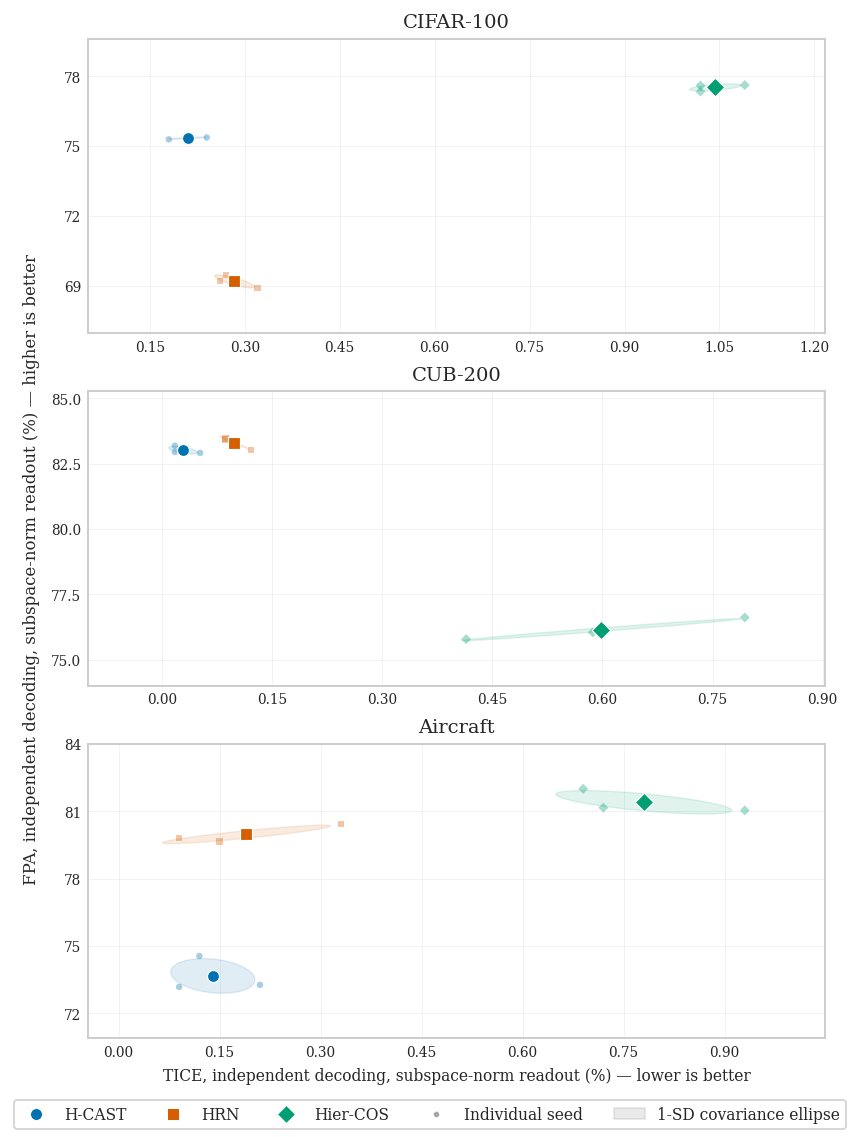

In [17]:
plot_tradeoff(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    encoding=ENCODING,
    # Every family is the subject here: one shared scale, no off-scale gutters.
    freeze_on_focal=False,
    # No family is the origin, so no crosshair through one of them.
    baseline_marker=None,
    decoder=DECODER, readout=READOUT,
)

## Level Accuracy

FPA is a whole-path metric, so a difference in it says nothing about *which*
level produced the difference. These bars decompose it into the coarse, middle,
and fine accuracies themselves.

Absolute values rather than deltas: a delta figure has to be measured from some
run, and across families that origin would be an arbitrary pick. The trade-off
above already shows the families relative to each other; this figure gives the
levels their own numbers, and a difference between two bars is read off directly.

Two caveats carry over from the trade-off figure. The families differ in
backbone, objective, and schedule at once, so the bars say **where** they differ
across the hierarchy, not why — this is a decomposition, not an ablation. And
error bars are the across-seed sample standard deviation of each family
separately; `dataset.split_seed` is fixed at 0 in every preset, so all seeds and
all families share one train/validation split and the seed drives only
initialisation and data order.

Bars start at zero and each panel carries its own vertical scale, because
accuracy ranges differ across datasets; the printed values carry the
magnitudes.

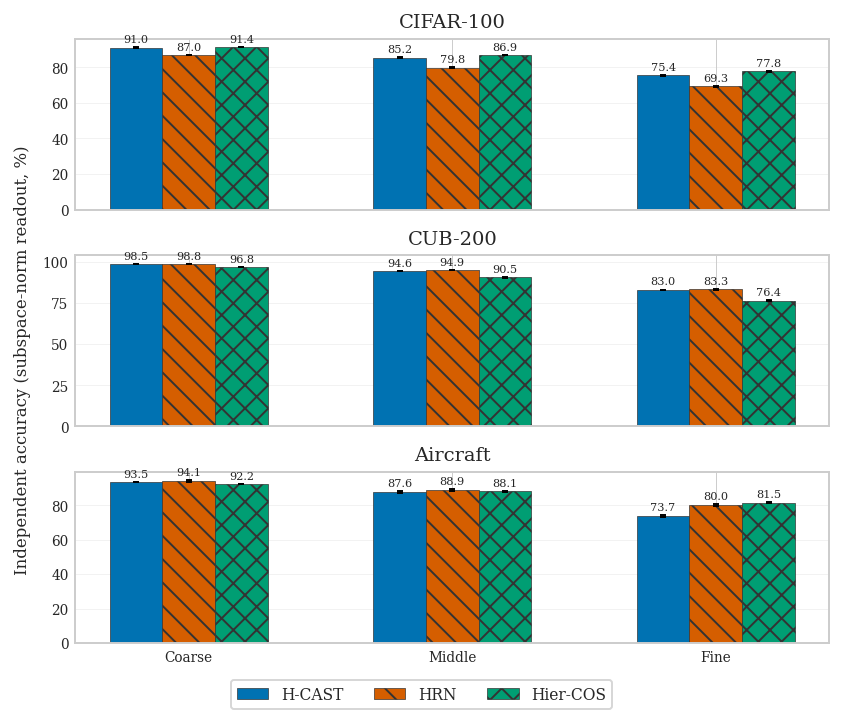

In [18]:
plot_level_accuracy(
    rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    decoder=DECODER, readout=READOUT,
)

## Run and Pareto Summary

Unlike the single-family notebooks, the Pareto test here runs **across model
families**: a family is Pareto-optimal within a dataset when no other *selected*
family has both higher-or-equal FPA and lower-or-equal TICE, with at least one
strict improvement. The test is relative to `MODELS`, so dropping a family can
promote a row that it dominated; report the selection alongside the verdict. Given the recipe differences above, read a Pareto-optimal row as
"no other family in this study dominates it on both axes at once", not as a
claim that the architecture is better.

AHD and weighted AP are reported as additional columns but do not enter the
Pareto test. The `epoch` column is the selected checkpoint's epoch, not the
budget, so it is not comparable across families with different budgets.

In [19]:
print_summary(rows, DATASETS, label_width=12)


CIFAR-100
  run           n  epoch           FPA               TICE              AHD               weighted AP       status
  Hier-COS      3  93.7 ± 5.0      77.52% ± 0.16     1.04% ± 0.04      0.444 ± 0.003     80.07% ± 0.20     Pareto-optimal
  H-CAST        3  97.3 ± 2.3      75.34% ± 0.05     0.21% ± 0.03      0.485 ± 0.006     77.91% ± 0.10     Pareto-optimal
  HRN           3  90.3 ± 0.6      69.19% ± 0.29     0.28% ± 0.03      0.641 ± 0.003     72.02% ± 0.23     dominated by H-CAST

CUB-200
  run           n  epoch           FPA               TICE              AHD               weighted AP       status
  HRN           3  79.0 ± 23.6     83.31% ± 0.24     0.10% ± 0.02      0.230 ± 0.003     85.89% ± 0.17     Pareto-optimal
  H-CAST        3  82.7 ± 14.0     83.02% ± 0.15     0.03% ± 0.02      0.238 ± 0.001     85.59% ± 0.12     Pareto-optimal
  Hier-COS      3  71.7 ± 16.3     76.15% ± 0.42     0.60% ± 0.19      0.366 ± 0.006     79.58% ± 0.34     dominated by H-CAST, HRN

Airc

## Frozen baselines under the subspace-norm readout

The native figure above compares the inference rule each family was designed to use.
For the frozen-baseline inference study, this second view holds the independently
selected checkpoints fixed and applies the same probability-space `subspace_norm`
readout to H-CAST, HRN and Hier-COS. It is generated in addition to, rather than in
place of, the all-family native view. Restricting the plot to the three leading
baselines keeps their changed Pareto frontier legible.

The readout is a strong default but not a universal winner: the thesis table retains
LH-DNN and the HT-CapsNet CUB-200 and Aircraft failures, and the figure caption makes
the display-only restriction explicit.


CIFAR-100 frozen model baselines, subspace-norm readout
  H-CAST                      3 seed(s): hcast_cifar100
  HRN                         3 seed(s): hrn_cifar100_level_conditional
  Hier-COS                    3 seed(s): hiercos_cifar100_global_softmax_ce_reg_baseline_kl_leaf

CUB-200 frozen model baselines, subspace-norm readout
  H-CAST                      3 seed(s): hcast_cub200
  HRN                         3 seed(s): hrn_cub200_level_conditional
  Hier-COS                    3 seed(s): hiercos_cub200_global_softmax_ce_reg_baseline_kl_leaf

Aircraft frozen model baselines, subspace-norm readout
  H-CAST                      3 seed(s): hcast_aircraft
  HRN                         3 seed(s): hrn_aircraft_level_conditional
  Hier-COS                    3 seed(s): hiercos_aircraft_global_softmax_ce_reg_baseline_kl_leaf
  encoding OK (9 rows, 3 panels)


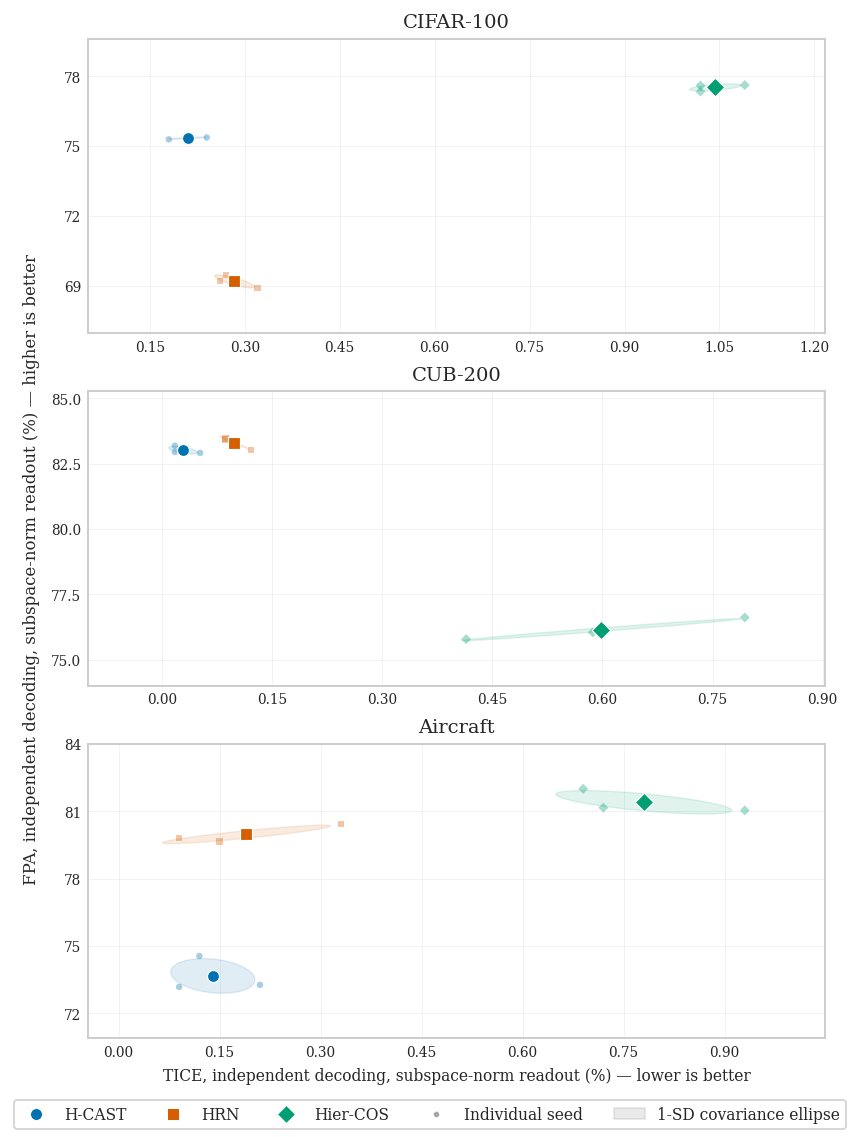


CIFAR-100
  run           n  epoch           FPA               TICE              AHD               weighted AP       status
  Hier-COS      3  93.7 ± 5.0      77.52% ± 0.16     1.04% ± 0.04      0.444 ± 0.003     80.07% ± 0.20     Pareto-optimal
  H-CAST        3  97.3 ± 2.3      75.34% ± 0.05     0.21% ± 0.03      0.485 ± 0.006     77.91% ± 0.10     Pareto-optimal
  HRN           3  90.3 ± 0.6      69.19% ± 0.29     0.28% ± 0.03      0.641 ± 0.003     72.02% ± 0.23     dominated by H-CAST

CUB-200
  run           n  epoch           FPA               TICE              AHD               weighted AP       status
  HRN           3  79.0 ± 23.6     83.31% ± 0.24     0.10% ± 0.02      0.230 ± 0.003     85.89% ± 0.17     Pareto-optimal
  H-CAST        3  82.7 ± 14.0     83.02% ± 0.15     0.03% ± 0.02      0.238 ± 0.001     85.59% ± 0.12     Pareto-optimal
  Hier-COS      3  71.7 ± 16.3     76.15% ± 0.42     0.60% ± 0.19      0.366 ± 0.006     79.58% ± 0.34     dominated by H-CAST, HRN

Airc

In [20]:
FROZEN_READOUT = 'subspace_norm'
FROZEN_MODELS = ('hcast', 'hrn', 'hiercos')
FROZEN_RUN_SPECS = [spec for spec in RUN_SPECS if spec['key'] in FROZEN_MODELS]

evaluate_missing_readouts(
    OUTPUTS_ROOT, DATASETS, FROZEN_RUN_SPECS,
    decoder='independent', readout=FROZEN_READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
    run_evaluation=RUN_INFERENCE, overwrite=OVERWRITE_INFERENCE,
    device=INFERENCE_DEVICE,
)

subspace_rows, subspace_missing = discover_rows(
    OUTPUTS_ROOT, DATASETS, FROZEN_RUN_SPECS,
    decoder='independent', readout=FROZEN_READOUT,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)
subspace_encoding = encode_rows(
    subspace_rows,
    hue=('model', MODEL_COLORS),
    shape=('model', MODEL_MARKERS),
)

print_availability(subspace_rows, subspace_missing, DATASETS,
                   title='frozen model baselines, subspace-norm readout')
check_encoding(subspace_rows, datasets=DATASETS)
plot_tradeoff(
    subspace_rows, DATASETS, FIGURE_DIR, SAVE_FIGURES,
    encoding=subspace_encoding, freeze_on_focal=False,
    baseline_marker=None, decoder='independent', readout=FROZEN_READOUT,
)
print_summary(subspace_rows, DATASETS, label_width=12)